# 1 · ESRS-RAG — Retrieval evaluation

A question-answering assistant over the **12 ESRS standards** (EU sustainability reporting,
Commission Delegated Regulation (EU) 2023/2772). This notebook reports **how well the retrieval
stage works**, measured the way a forecasting model is measured: **against baselines, as a skill
score, never as a bare absolute number**.

**The primary configuration is Spanish questions against the Spanish corpus** — the real target
user asks in Spanish. All figures below are on the **37 evaluation questions that anchor to a
specific paragraph**; the anchoring is language-invariant, so cross-corpus comparisons are
apples-to-apples.

> This is a results notebook. The retrieval code (a hand-written BM25, the fusion, the exact-cosine
> search) lives outside it; here we only load precomputed results and read them.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# --- localizar el artefacto de resultados (funciona desde la raíz o desde notebooks/) ---
for _cand in ("eval/resultados_retrieval.json", "../eval/resultados_retrieval.json"):
    if Path(_cand).exists():
        R = json.loads(Path(_cand).read_text(encoding="utf-8"))
        break

# --- estilo y paleta (validada; el aleatorio en gris = suelo recesivo) ---
COL = {"aleatorio": "#8a8a86", "BM25": "#eb6834", "denso": "#2a78d6", "hibrido": "#1baf7a"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e5e2"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
})

def _limpia(ax, titulo, ylabel=None, ymax=None):
    ax.set_title(titulo, fontsize=11, fontweight="normal", loc="left", pad=8)
    if ylabel: ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, color=GRID, lw=1); ax.set_axisbelow(True)
    if ymax: ax.set_ylim(0, ymax)

def _etiqueta_barras(ax, barras, fmt="{:.2f}"):
    for b in barras:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.012, fmt.format(h),
                ha="center", va="bottom", fontsize=8, color=INK)

ES = R["escenarios"]["es_es"]        # escenario principal
EN = R["escenarios"]["es_en"]        # ablación cross-lingual
print(f"Loaded: {R['eval_set']['n_total']} questions "
      f"({R['meta']['n_preguntas_ancla']} anchored) · corpus {ES['corpus_n']} paragraphs")

Loaded: 45 questions (37 anchored) · corpus 1700 paragraphs


## The corpus

The 12 ESRS standards, extracted **structure-aware**: one record per numbered paragraph, glossary
entry or appendix row (**1,700 records** in Spanish). Chunking is one paragraph per chunk — so the
Spanish and English corpora have near-identical size (1,700 vs 1,697), which **neutralises the usual
length confounder** when comparing them.

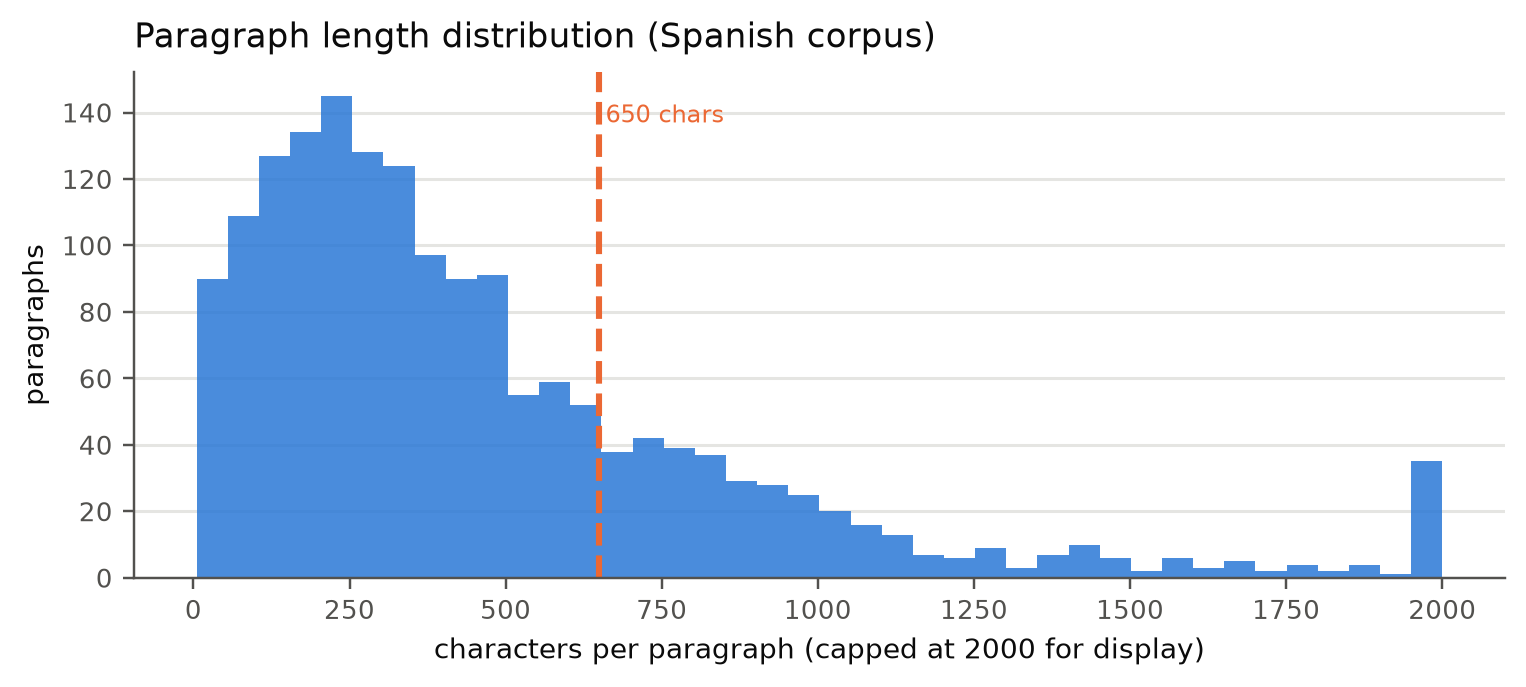

median 352 · mean 492.9 · p90 986 · max 5454 chars · 23.6% over 650 chars


In [2]:
lon = R["longitudes_corpus"]["es"]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([min(x, 2000) for x in lon["longitudes"]], bins=40, color=COL["denso"], alpha=0.85)
ax.axvline(650, color=COL["BM25"], lw=2, ls="--")
ax.text(660, ax.get_ylim()[1]*0.9, "650 chars", color=COL["BM25"], fontsize=8)
_limpia(ax, "Paragraph length distribution (Spanish corpus)", "paragraphs")
ax.set_xlabel("characters per paragraph (capped at 2000 for display)")
plt.tight_layout(); plt.show()
print(f"median {lon['mediana']} · mean {lon['media']} · p90 {lon['p90']} · "
      f"max {lon['max']} chars · {lon['pct_sobre_650']}% over 650 chars")

## The evaluation set

**45 questions, each hand-verified against the exact source paragraph**, with authorship and
verifier recorded per row — no LLM grades its own exam. Questions are written in **user language**,
not the wording of the standard, so semantic search has something real to prove over keyword search.

Each question has a **type**, so metrics can be broken down (as in the per-type chart later):

| type | what it asks | correct behaviour |
|---|---|---|
| **`requisito`** | what the standard *requires you to disclose* about X | retrieve the disclosure-requirement paragraph |
| **`fuera_de_corpus`** | something whose answer is **not in the corpus** | **abstain** ("not covered") |
| **`definicion`** | a glossary definition | retrieve the defined term |
| **`factual`** / **`factual_numerica`** | a specific fact / a specific number (threshold, year, %) | retrieve the paragraph stating it |
| **`error_de_categoria`** | "what should I **do**?" — but the ESRS only says what to **disclose** | **reframe**, not answer and not abstain |

The set is deliberately weighted toward `requisito` and **abstention** (`fuera_de_corpus`): the ESRS
is a *disclosure* standard (it says what to *report*, not what to *do*), so the hard cases are "the
answer is not here" and "you're asking the wrong kind of question" (`error_de_categoria`).

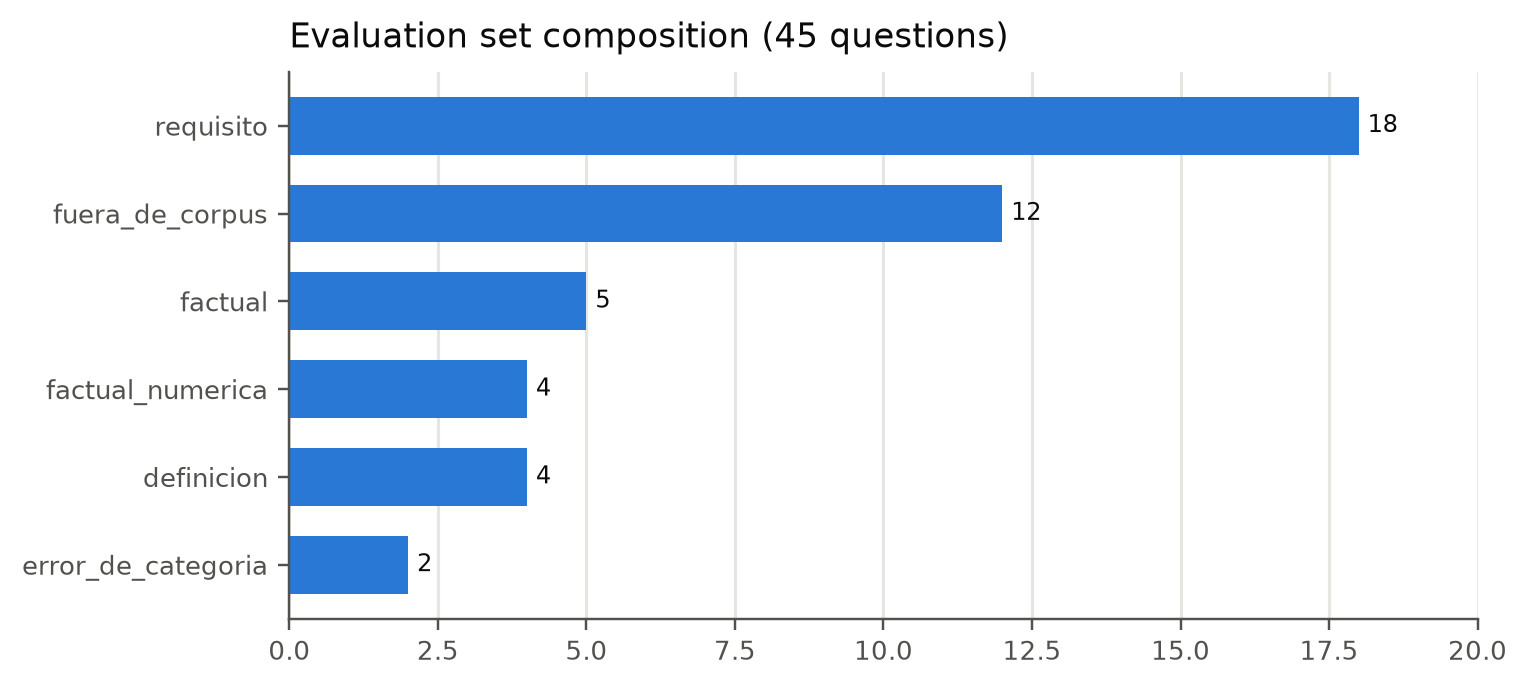

37 of 45 anchor to a paragraph (they enter recall); the rest are pure out-of-corpus (they feed the abstention metric).


In [3]:
tipos = R["eval_set"]["por_tipo"]
orden = sorted(tipos, key=tipos.get)
fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(orden, [tipos[t] for t in orden], color=COL["denso"], height=0.66)
for b, t in zip(barras, orden):
    ax.text(b.get_width()+0.15, b.get_y()+b.get_height()/2, str(tipos[t]),
            va="center", fontsize=8, color=INK)
_limpia(ax, "Evaluation set composition (45 questions)")
ax.xaxis.grid(True, color=GRID, lw=1); ax.yaxis.grid(False)
ax.set_xlim(0, max(tipos.values())+2)
plt.tight_layout(); plt.show()
print(f"{R['meta']['n_preguntas_ancla']} of 45 anchor to a paragraph (they enter recall); "
      f"the rest are pure out-of-corpus (they feed the abstention metric).")

## Retrieval: dense vs the baselines

Three retrievers on the primary configuration (Spanish → Spanish), plus a **hybrid** (dense + BM25):

- **random** — the trivial baseline (~0). Without it, a recall number says nothing.
- **BM25** — the *hard* baseline. Lexical (keyword) search, **hand-implemented** (Okapi, no library).
- **dense (e5)** — semantic search on multilingual embeddings. The system.

`recall@5 = 0.57` is a **modest starting point by design** — a corpus that scored 0.97 out of the
box would leave nothing to demonstrate. The gap is the room the ablations get to move.

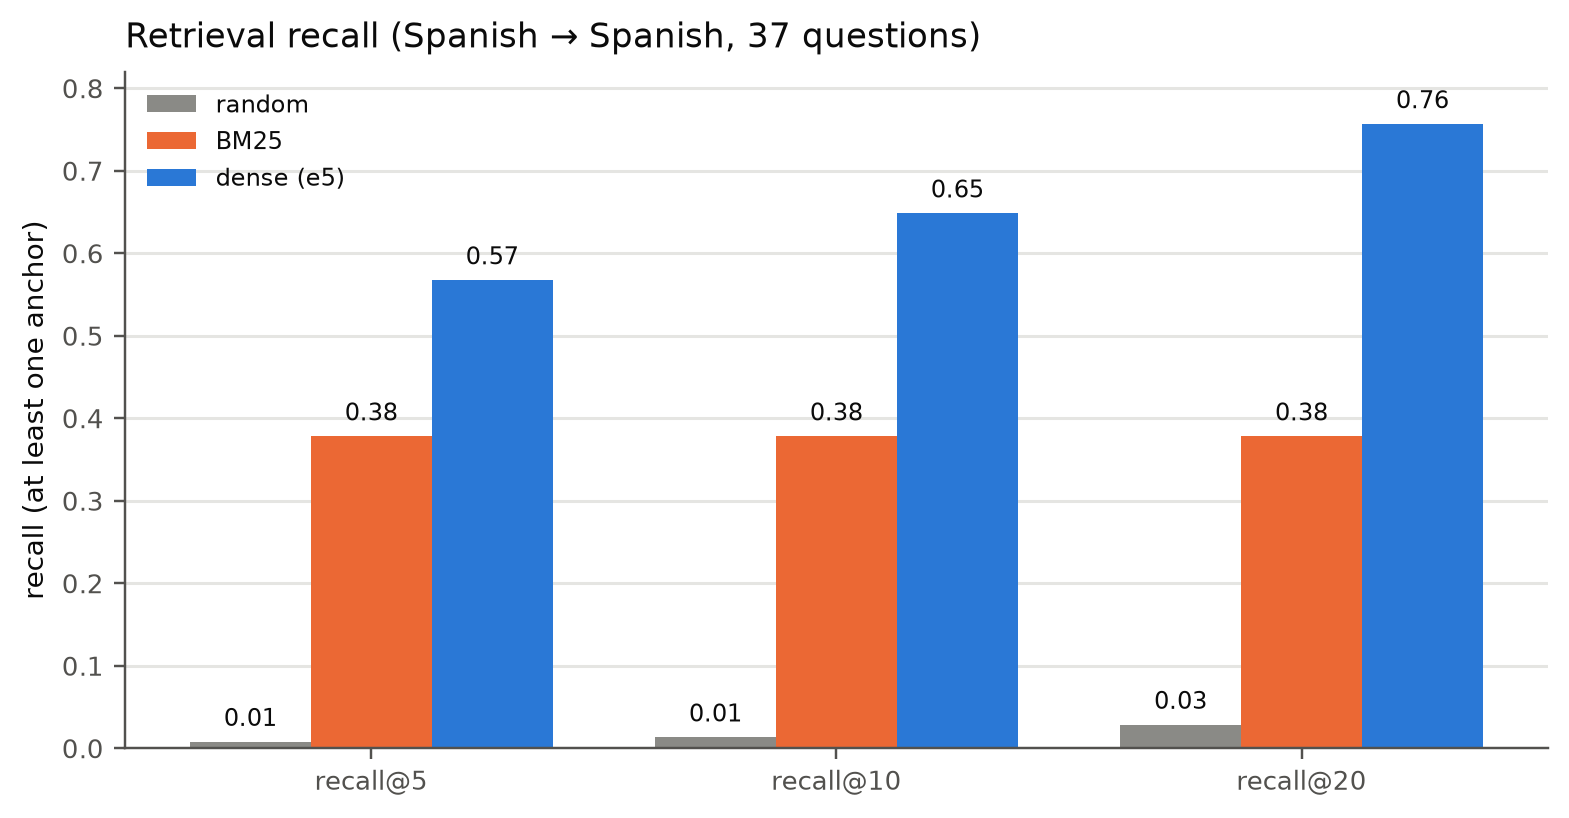

In [4]:
recs = ["aleatorio", "BM25", "denso"]
etiq = {"aleatorio": "random", "BM25": "BM25", "denso": "dense (e5)"}
ks = ["recall@5", "recall@10", "recall@20"]
x = np.arange(len(ks)); w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for i, r in enumerate(recs):
    vals = [ES["recuperadores"][r][k] for k in ks]
    b = ax.bar(x + (i-1)*w, vals, w, label=etiq[r], color=COL[r])
    _etiqueta_barras(ax, b)
_limpia(ax, "Retrieval recall (Spanish → Spanish, 37 questions)", "recall (at least one anchor)", 0.82)
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.legend(frameon=False, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

### Skill scores

The headline metric: **`SS = 1 − (1 − model) / (1 − baseline)`**. Here **`model` and `baseline` are
each the `recall@5` of a retriever** (the fraction of questions whose answer it found in the top 5),
so **`1 − recall` is that retriever's failure rate**. The score therefore asks: *what fraction of
the baseline's failures does the model eliminate?*

- `1` = perfect (no failures) · `0` = same as the baseline · **negative = worse than the baseline**.
- Example — **dense vs BM25**: `1 − (1 − 0.57)/(1 − 0.38) = 1 − 0.43/0.62 = +0.30`.

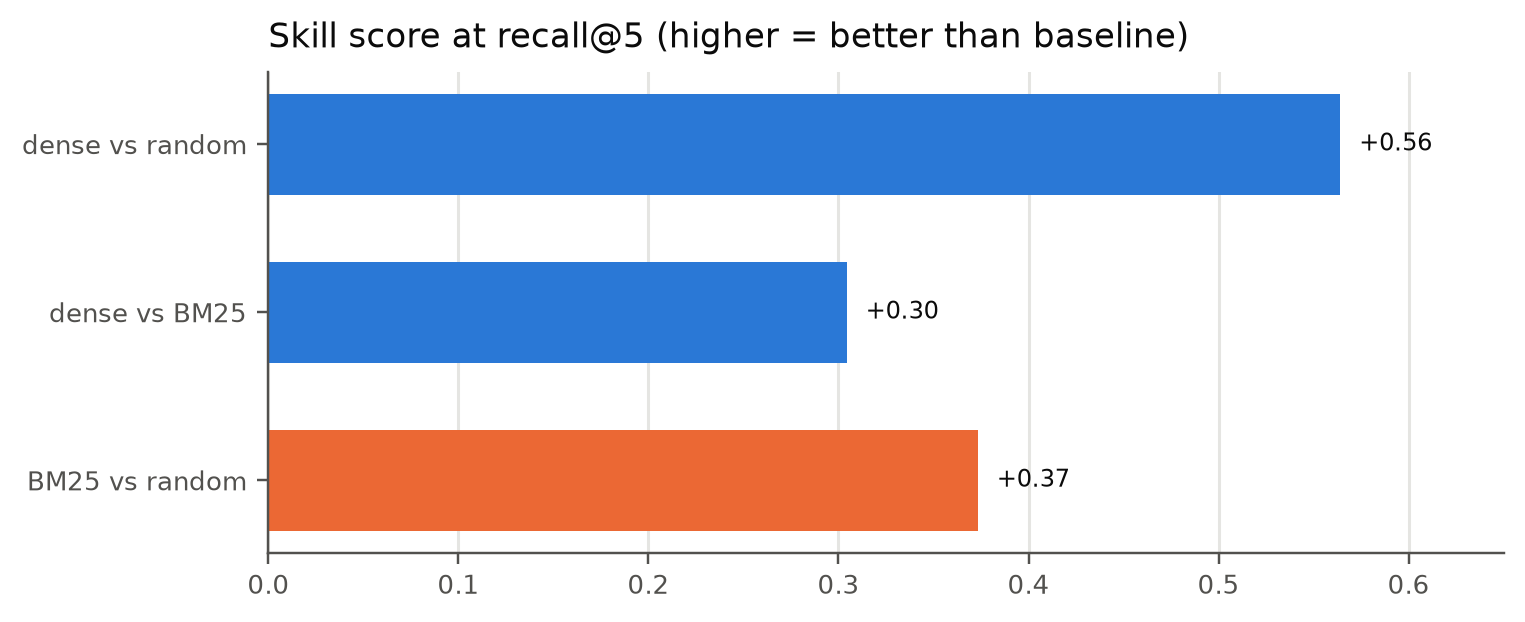

In [5]:
ss = ES["skill_scores"]
pares = [("dense vs random", ss["denso_vs_aleatorio"], COL["denso"]),
         ("dense vs BM25",   ss["denso_vs_bm25"],      COL["denso"]),
         ("BM25 vs random",  ss["bm25_vs_aleatorio"],  COL["BM25"])]
fig, ax = plt.subplots(figsize=(7, 2.9))
for i, (nom, v, c) in enumerate(pares):
    ax.barh(i, v, color=c, height=0.6)
    ax.text(v+0.01, i, f"+{v:.2f}", va="center", fontsize=8, color=INK)
ax.set_yticks(range(len(pares))); ax.set_yticklabels([p[0] for p in pares])
_limpia(ax, "Skill score at recall@5 (higher = better than baseline)")
ax.xaxis.grid(True, color=GRID, lw=1); ax.yaxis.grid(False); ax.set_xlim(0, 0.65)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Lexical retrieval collapses across languages

The same hand-written BM25, on the **same 37 Spanish questions**, against the Spanish corpus vs the
English one. Dense (multilingual) barely notices the language gap; **BM25 falls off a cliff** — a
Spanish query shares almost no tokens with English text. This is the strongest argument for
multilingual *semantic* retrieval, and it is **measured, not asserted**.

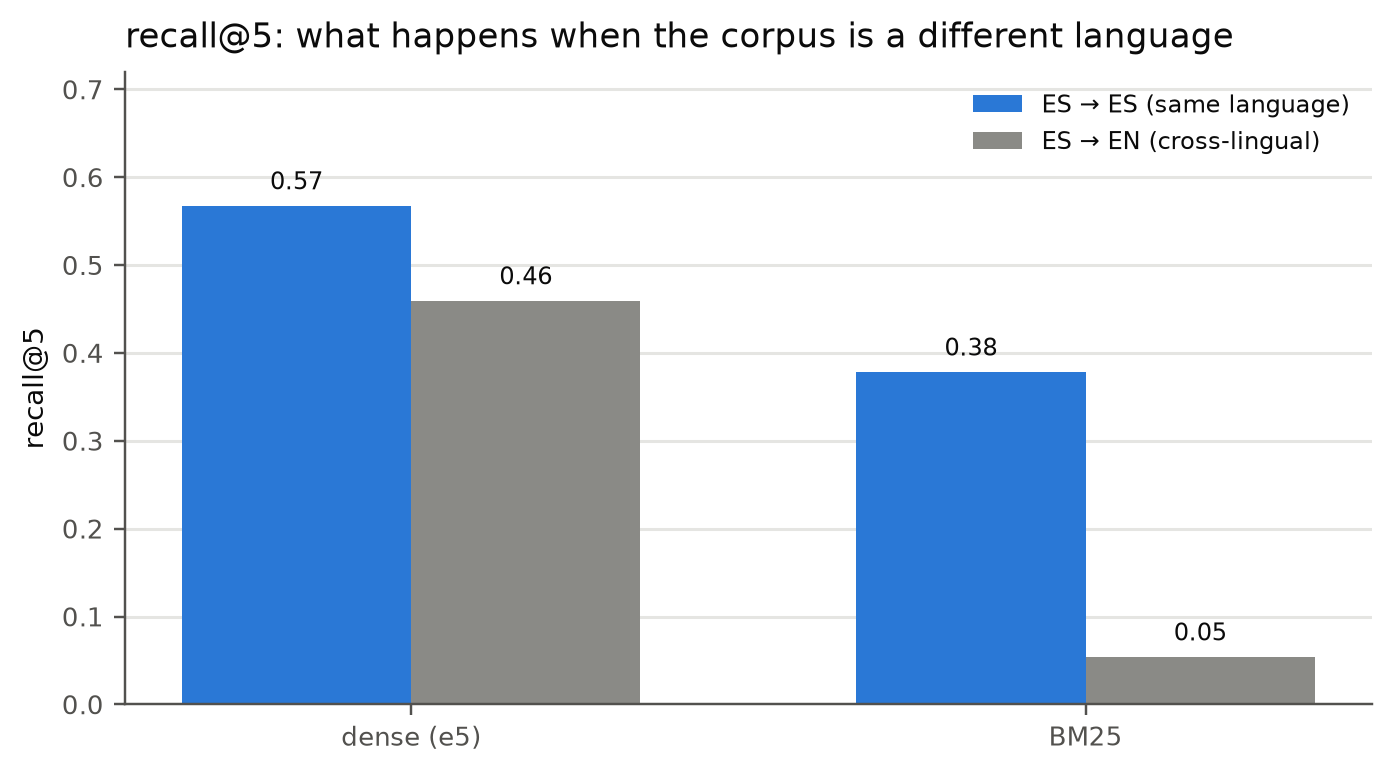

In [6]:
labels = ["dense (e5)", "BM25"]
eses = [ES["recuperadores"]["denso"]["recall@5"], ES["recuperadores"]["BM25"]["recall@5"]]
esen = [EN["recuperadores"]["denso"]["recall@5"], EN["recuperadores"]["BM25"]["recall@5"]]
x = np.arange(len(labels)); w = 0.34
fig, ax = plt.subplots(figsize=(6.4, 3.6))
b1 = ax.bar(x - w/2, eses, w, label="ES → ES (same language)", color=COL["denso"])
b2 = ax.bar(x + w/2, esen, w, label="ES → EN (cross-lingual)", color=COL["aleatorio"])
_etiqueta_barras(ax, b1); _etiqueta_barras(ax, b2)
_limpia(ax, "recall@5: what happens when the corpus is a different language", "recall@5", 0.72)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## The hybrid: an honest arc

BM25 and dense fail on *different* questions, so fusing them (Reciprocal Rank Fusion) *should* help.
It does not — not naively. **Equal-weight fusion makes recall worse** (`skill vs dense = −0.31`): RRF
regresses toward the weaker retriever, and BM25's noise pushes dense's correct hits out of the top-k.

Down-weighting BM25 (`w`) and sweeping the weight recovers a **real gain in ranking quality
(MRR 0.32 → 0.38)** — but **not in top-5 recall**, where every delta stays within noise (~1 question
of 37). So the honest conclusion is reported as-is: *the light hybrid improves the ranking, not the
hit rate*, and the recall deltas are not trusted.

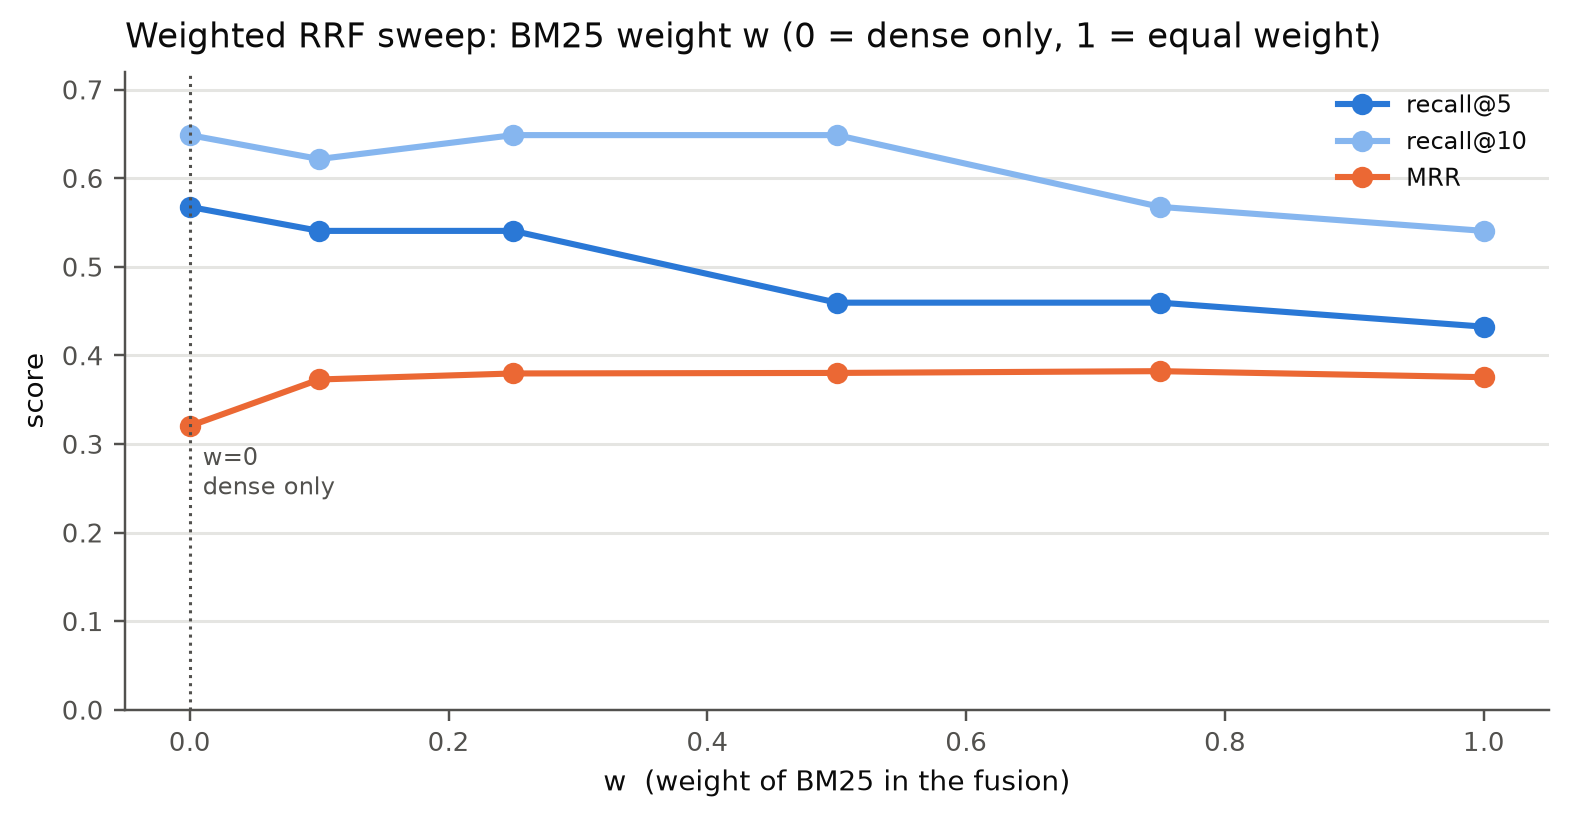

In [7]:
sw = ES["barrido_w"]
ws = [r["w"] for r in sw]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(ws, [r["recall@5"] for r in sw],  "-o", color=COL["denso"], lw=2, ms=6, label="recall@5")
ax.plot(ws, [r["recall@10"] for r in sw], "-o", color="#86b6ef",    lw=2, ms=6, label="recall@10")
ax.plot(ws, [r["mrr"] for r in sw],       "-o", color=COL["BM25"],  lw=2, ms=6, label="MRR")
ax.axvline(0, color=INK2, lw=1, ls=":")
ax.text(0.01, 0.30, "w=0\ndense only", color=INK2, fontsize=8, va="top")
_limpia(ax, "Weighted RRF sweep: BM25 weight w (0 = dense only, 1 = equal weight)", "score", 0.72)
ax.set_xlabel("w  (weight of BM25 in the fusion)")
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

### Where BM25 helps: by question type

The per-type view shows *why* the hybrid isn't useless even though it loses overall: the **fusion**
reaches the two small buckets where dense scores **zero** — `error_de_categoria` and `fuera_de_corpus`
— by combining weak rank signals from both retrievers (neither pure retriever gets them alone), while
**costing** on the large `requisito` bucket. Both buckets are tiny (`error_de_categoria` is 2
questions), so net at `recall@5` the cost on `requisito` outweighs the rescue; the value shows up in
the ranking (MRR), not the hit rate.

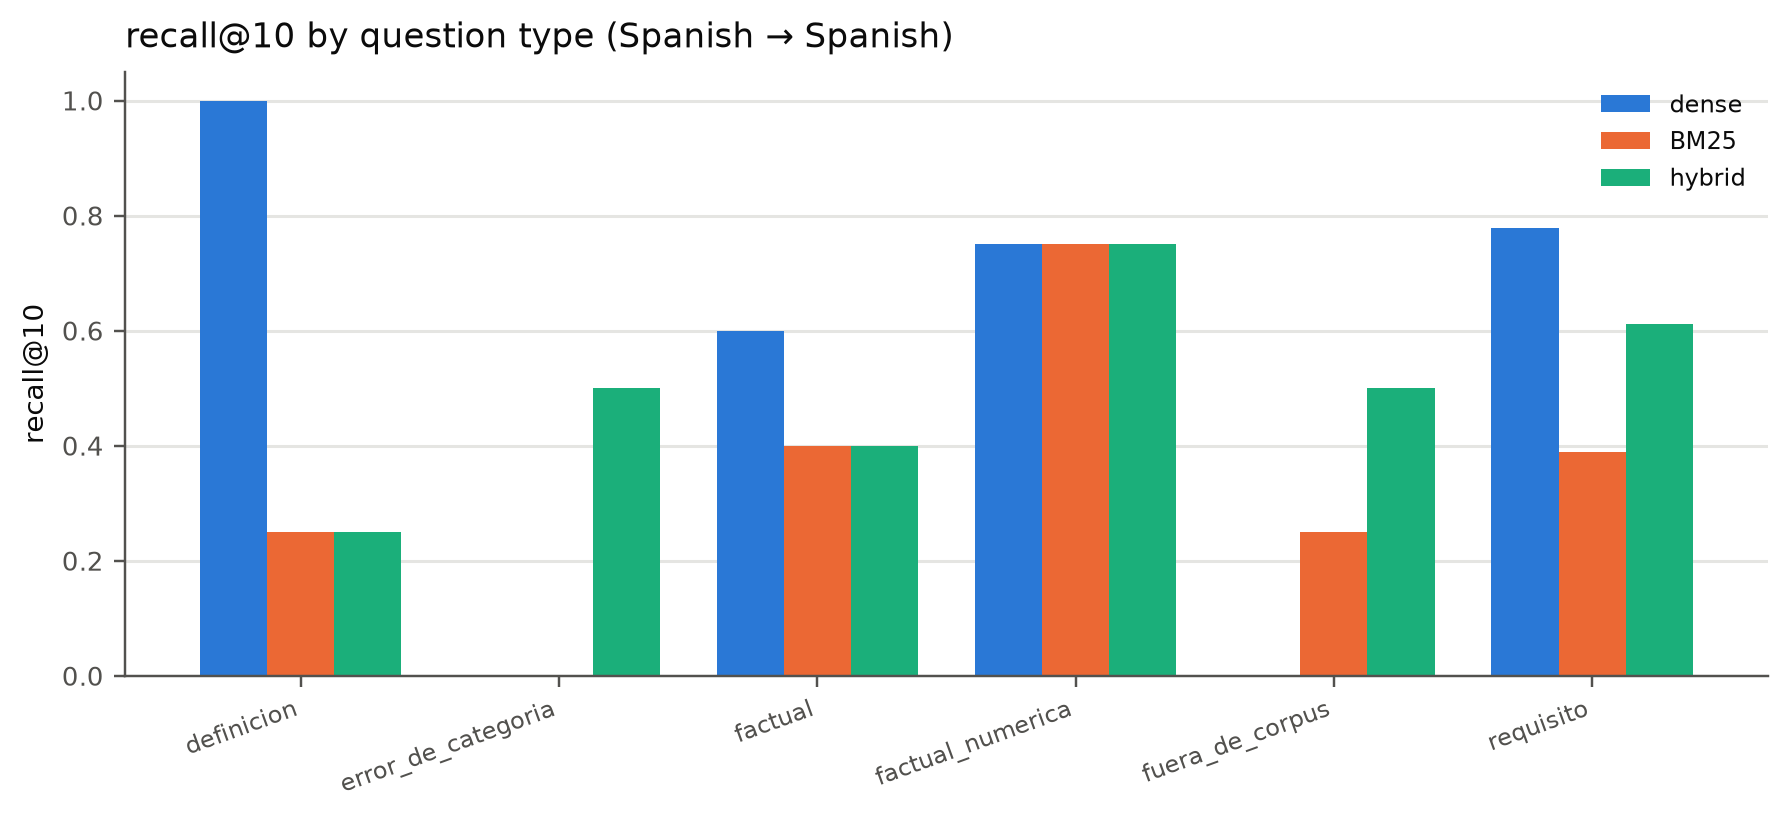

In [8]:
pt = ES["recall10_por_tipo"]
tipos = list(pt["denso"].keys())
x = np.arange(len(tipos)); w = 0.26
fig, ax = plt.subplots(figsize=(8.2, 3.8))
for i, (r, lab) in enumerate([("denso", "dense"), ("bm25", "BM25"), ("hibrido", "hybrid")]):
    col = {"denso": COL["denso"], "bm25": COL["BM25"], "hibrido": COL["hibrido"]}[r]
    ax.bar(x + (i-1)*w, [pt[r][t] for t in tipos], w, label=lab, color=col)
_limpia(ax, "recall@10 by question type (Spanish → Spanish)", "recall@10", 1.05)
ax.set_xticks(x); ax.set_xticklabels(tipos, rotation=20, ha="right", fontsize=8)
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## Contamination bias, quantified

Some questions were written by the author *while reading the source paragraph* (reusing its words);
the rest are hand-written user-language questions. The first group is easier for retrieval — and the
gap is **measured**, not hidden: it is reported next to the headline numbers so the reader can
discount it.

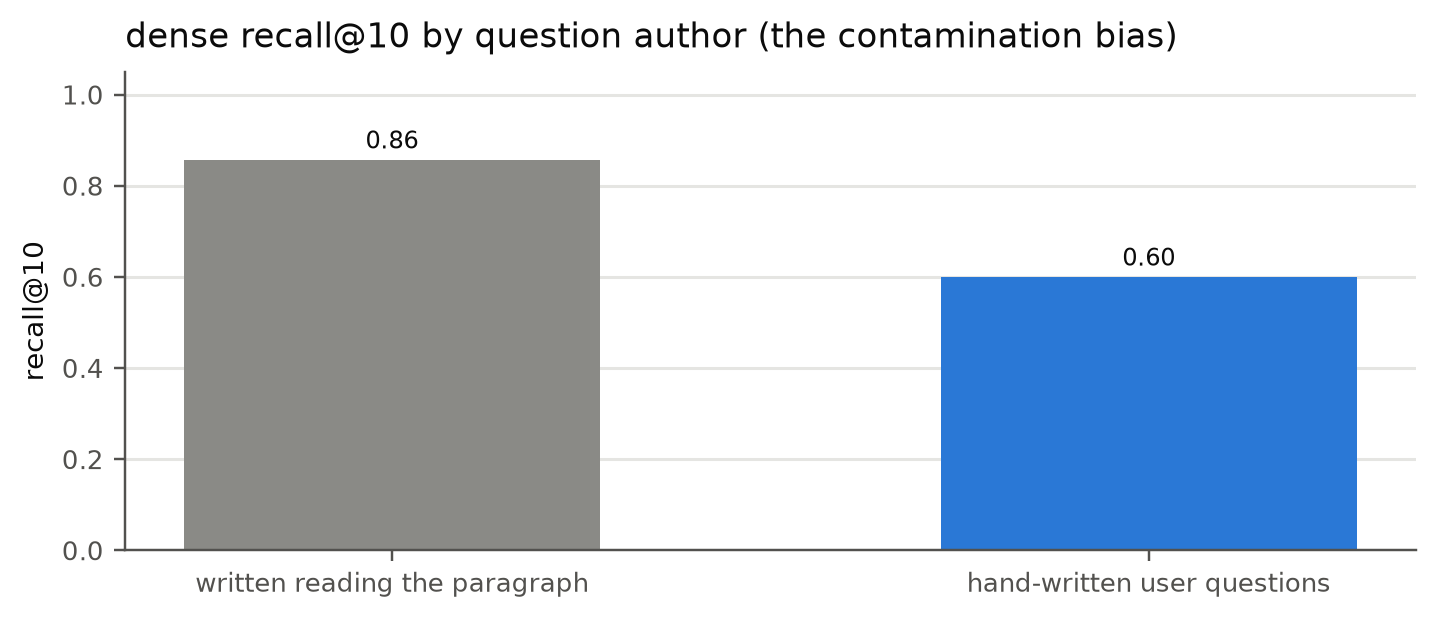

In [9]:
au = ES["recall10_por_autor"]["denso"]
nombres = {"Claude": "written reading the paragraph", "humano": "hand-written user questions"}
claves = ["Claude", "humano"]
fig, ax = plt.subplots(figsize=(6.6, 2.9))
b = ax.bar([nombres[k] for k in claves], [au[k] for k in claves],
           color=[COL["aleatorio"], COL["denso"]], width=0.55)
_etiqueta_barras(ax, b)
_limpia(ax, "dense recall@10 by question author (the contamination bias)", "recall@10", 1.05)
plt.tight_layout(); plt.show()

## A note on reproducibility

While building this notebook, the hybrid's numbers **changed between runs** (`recall@5` = 0.42 /
0.45 / 0.40) while dense, BM25 and random were rock-stable. Cause: the vector store's approximate
(HNSW) search has a **non-deterministic tail** (positions ~20–100); its top-20 was stable, so dense
recall didn't move — but RRF sums over the whole tail, so the fusion inherited the wobble.

Fixed by replacing the approximate query with **exact cosine search** (trivial for 1,700 vectors),
which makes every number here reproducible. Caught by *comparing runs*, not by trusting a green
result — the same discipline as fixing a random seed before reporting a metric.

## What's next

- **Generation** — covered in **notebook 2**: grounded answers with a local LLM, measured for
  answer rate, abstention and hallucination (the faithfulness ↔ answer-rate trade-off).
- **Tuning ablations** — chunk-size and `k` sweeps, to fix the deployed configuration by measurement.

*Runs 100% on-premise: no external APIs, no credentials, no document leaves the machine.*